# FATHOM - combine and scale

This notebook performs two steps:
1. Combine the three types of FATHOM flood (pluvial, fluvial, coastal) into a single layer of maximum flood depth.  
2. Scale the combined layer to match the 1km resolution GHS-POP layer, aggregating the data at the following classification  
  i. Proportion of 30m cells within each 1km grid cell where maximum flood depth exceeds 0.5m  
  ii. Proportion where maximum flood depth exceeds 0.15m  
  iii. Proportion where maximum flood depth exceeds 0m  

In [17]:
import os, time, io, json, sys
import urllib3
import boto3
import rasterio

import geopandas as gpd
import pandas as pd
import numpy as np

from functools import reduce
from urllib3.exceptions import InsecureRequestWarning
from botocore import UNSIGNED
from botocore.config import Config
from tqdm.notebook import tqdm

urllib3.disable_warnings(InsecureRequestWarning)

def tPrint(s):
    """prints the time along with the message"""
    print("%s\t%s" % (time.strftime("%H:%M:%S"), s))

s3_client = boto3.client('s3', verify=False)

sys.path.insert(0, "C:/WBG/Work/Code/GOSTrocks/src")

import GOSTrocks.dataMisc as dataMisc
import GOSTrocks.rasterMisc as rMisc

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
local_folder = "C:/WBG/Work/Projects/FATHOM_COLLAPSE"
out_folder = os.path.join(local_folder, "FATHOM_summaries")
map_folder = os.path.join(local_folder, "FATHOM_maps")
for tF in [out_folder, map_folder]:
    if not os.path.exists(tF):
        os.makedirs(tF)

ghs_pop_file = "C:\\WBG\\Work\\data\\URBAN\\SMOD_POP\\GHS_POP_E2025_GLOBE_R2023A_54009_1000_V1_0.tif"

s3_bucket = "wbg-geography01"
s3_prefix = "FATHOM"
return_period = 100
flood_files = [
    ["FU", "FLOOD_MAP-1ARCSEC-NW_OFFSET-1in{rp}-FLUVIAL-UNDEFENDED-DEPTH-2020-PERCENTILE50-v3.1.vrt"],
    ["CU", "FLOOD_MAP-1ARCSEC-NW_OFFSET-1in{rp}-COASTAL-UNDEFENDED-DEPTH-2020-PERCENTILE50-v3.1.vrt"],
    ['PD', "FLOOD_MAP-1ARCSEC-NW_OFFSET-1in{rp}-PLUVIAL-DEFENDED-DEPTH-2020-PERCENTILE50-v3.1.vrt"]
]

In [3]:
# Use the S3 client to get a list of VRT files in the specified bucket and prefix
response = s3_client.list_objects_v2(Bucket=s3_bucket, Prefix=s3_prefix)
vrt_files = [obj['Key'] for obj in response.get('Contents', []) if obj['Key'].endswith('.vrt')]

# Turn the list of vrt files into a dataframe
vrt_breakdown = [[x] + x.split('-') for x in vrt_files]
vrt_df = pd.DataFrame(vrt_breakdown, columns=["path", 'prefix', 'res', 'offset', 'return_period', 'hazard', 'defended', 'metric', 'year', 'scenario', 'version', "other"])
vrt_df = vrt_df.loc[:, ['return_period', 'hazard', 'defended', 'year', 'scenario', "path"]]

# Focus on just the 100-year return period for now
vrt_df = vrt_df[vrt_df['return_period'] == f"1in{return_period}"]
# Drop the undefended models
vrt_df = vrt_df[vrt_df['defended'] == "DEFENDED"]
vrt_df

,return_period,hazard,defended,year,scenario,path
65,1in100,COASTAL,DEFENDED,2020,PERCENTILE50,FATHOM/FLOOD_MAP-1ARCSEC-NW_OFFSET-1in100-COAS...
66,1in100,COASTAL,DEFENDED,2030,SSP1_2.6,FATHOM/FLOOD_MAP-1ARCSEC-NW_OFFSET-1in100-COAS...
67,1in100,COASTAL,DEFENDED,2030,SSP2_4.5,FATHOM/FLOOD_MAP-1ARCSEC-NW_OFFSET-1in100-COAS...
68,1in100,COASTAL,DEFENDED,2030,SSP3_7.0,FATHOM/FLOOD_MAP-1ARCSEC-NW_OFFSET-1in100-COAS...
69,1in100,COASTAL,DEFENDED,2030,SSP5_8.5,FATHOM/FLOOD_MAP-1ARCSEC-NW_OFFSET-1in100-COAS...
70,1in100,COASTAL,DEFENDED,2050,SSP1_2.6,FATHOM/FLOOD_MAP-1ARCSEC-NW_OFFSET-1in100-COAS...
71,1in100,COASTAL,DEFENDED,2050,SSP2_4.5,FATHOM/FLOOD_MAP-1ARCSEC-NW_OFFSET-1in100-COAS...
72,1in100,COASTAL,DEFENDED,2050,SSP3_7.0,FATHOM/FLOOD_MAP-1ARCSEC-NW_OFFSET-1in100-COAS...
73,1in100,COASTAL,DEFENDED,2050,SSP5_8.5,FATHOM/FLOOD_MAP-1ARCSEC-NW_OFFSET-1in100-COAS...
74,1in100,COASTAL,DEFENDED,2080,SSP1_2.6,FATHOM/FLOOD_MAP-1ARCSEC-NW_OFFSET-1in100-COAS...


In [4]:
vrt_df.groupby(['year','scenario']).size()

year  scenario    
2020  PERCENTILE50    3
2030  SSP1_2.6        3
      SSP2_4.5        3
      SSP3_7.0        3
      SSP5_8.5        3
2050  SSP1_2.6        3
      SSP2_4.5        3
      SSP3_7.0        3
      SSP5_8.5        3
2080  SSP1_2.6        3
      SSP2_4.5        3
      SSP3_7.0        3
      SSP5_8.5        3
dtype: int64

<Axes: >

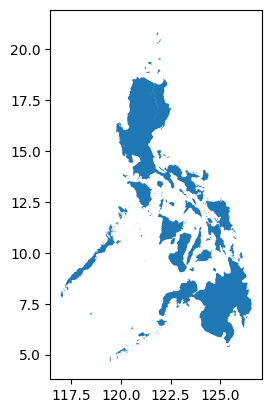

In [7]:
# Fetch the national boundaries from the official World Bank sources
iso3 = "PHL"
national_boundaries = dataMisc.download_wb_boundaries("ADM0", iso3)
national_boundaries.plot()

In [49]:
# select the year and model to work with and extract the data from the vrt
year = "2020"
scenario = "PERCENTILE50"
depth_thresh = [0,15,50]
sel_models = vrt_df[(vrt_df['year'] == year) & (vrt_df['scenario'] == scenario)]

fluvial_path = "s3://{bucket}/{path}".format(bucket=s3_bucket, path=sel_models[sel_models['hazard'] == "FLUVIAL"]['path'].values[0])
coastal_path = "s3://{bucket}/{path}".format(bucket=s3_bucket, path=sel_models[sel_models['hazard'] == "COASTAL"]['path'].values[0])
pluvial_path = "s3://{bucket}/{path}".format(bucket=s3_bucket, path=sel_models[sel_models['hazard'] == "PLUVIAL"]['path'].values[0])

ghs_r = rasterio.open(ghs_pop_file)
ghs_data, ghs_meta = rMisc.clipRaster(ghs_r, national_boundaries, None, True)


In [51]:
with rasterio.Env(GDAL_HTTP_UNSAFESSL='YES'):    
    fluvial_data, fluvial_meta = rMisc.clipRaster(fluvial_path, national_boundaries)
    coastal_data, coastal_meta = rMisc.clipRaster(coastal_path, national_boundaries)
    pluvial_data, pluvial_meta = rMisc.clipRaster(pluvial_path, national_boundaries)
    # Stack the rasters together and take the max value across the stack to get the combined flood depth
    max_depth = np.maximum.reduce([fluvial_data, coastal_data, pluvial_data])
    for cDepth in depth_thresh:
        combined_data = np.where(max_depth > cDepth, 1, 0)
        out_file = os.path.join(out_folder, f"{iso3}_FATHOM_combined_{year}_{scenario}_thresh{cDepth}.tif")
        with rMisc.create_rasterio_inmemory(fluvial_meta, combined_data) as fathom_depth:
            with rMisc.create_rasterio_inmemory(ghs_meta, ghs_data) as ghs_local:
                rMisc.standardizeInputRasters(fathom_depth, ghs_local, out_file, resampling_type="sum")

    
        
    

CPLE_AppDefinedError: Deleting C:/WBG/Work/Projects/FATHOM_COLLAPSE\FATHOM_summaries\PHL_FATHOM_combined_2020_PERCENTILE50_thresh15.tif failed: Permission denied